# 1.1 Acoustic Modeling Basics

This tutorial is the canonical first FrequenSolve example. It builds a two-layer acoustic model, writes a project, runs a frequency-domain job first, reconstructs time-domain traces from a frequency sweep, and requests ParaView output.

Behind the scenes, FrequenSolve is primarily driven by frequency-domain simulation (so you won't find a CFL condition), although we've tried to make time-domain modelling equally convenient. A `FrequencyDomainJob` asks for one or more explicit frequencies and is the most direct way to inspect solver inputs, logs, fields, and frequency-domain traces. A `TimeDomainJob` is a convenience layer: it expands the requested time window and bandwidth into the necessary frequency simulations, then transforms the frequency-domain responses back to time-domain traces.

The example uses flat interfaces and constant per-layer material properties so the project structure, mesh controls, boundary conditions, acquisition, jobs, and outputs are easy to inspect.


## API Concepts

A FrequenSolve project owns simulations and jobs. A simulation contains the physical model, mesh, boundary conditions, acquisition, numerics, units, and coordinate systems. Jobs select the workflow and output requests. Sites run jobs and return handles/results.

The first three Modeling Basics notebooks intentionally use the same flat two-layer geometry and shared material values. Acoustic uses only compressional wave propagation (`Vp` and `Rho`); elastic reuses those values and adds shear-wave speed (`Vs`); poroelastic reuses the elastic frame and adds pore-fluid and transport properties. That progression makes the additional physics visible without changing the background model.

This notebook uses a free top boundary and PML on the sides and bottom. The reference tables below list the acoustic material properties and boundary-condition names accepted by the public API for this physics family.


## Modeling Workflow

This notebook follows the same pattern used throughout the tutorial collection:

1. Define the physical vocabulary: physics, units, material properties, and boundary conditions (we'll return to units later).
2. Build a small model whose geometry and properties can be inspected visually.
3. Add a mesh generator and acquisition geometry.
4. Submit a frequency-domain job, inspect fields/logs, then submit a time-domain job that synthesizes traces from a frequency sweep.

If you are new to the package, this is the mental model to keep: Python objects are the authoring API, project files are the solver contracts, and result handles are the bridge back to analysis objects such as `TraceDataset`.


In [1]:
from IPython.display import Image, display
from pathlib import Path
import numpy as np
import frequensolve as fs

u = fs.ureg


## Project And Simulation

The project path is the root for saved JSON, HDF5 inputs, job files, logs, and results. The notebook writes into `./scratch/tutorials/simple_acoustic`.


In [2]:
project = fs.Project(
    name="project",
    path="./scratch/acoustic",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="acoustic_basic",
    physics="acoustic",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)

## Acoustic Material Properties

Start by deciding which material properties the physics needs. Acoustic physics is the smallest supported material model: `Vp` controls compressional wave speed and wavelength, while `Rho` controls impedance and reflection strength. These `Vp` and `Rho` values are reused in the elastic and poroelastic notebooks so the early physics examples build on the same background model.

| Property | Unit | upper_layer | lower_layer | Meaning |
| --- | --- | ---: | ---: | --- |
| `Vp` | km/s | 2.0 | 2.8 | Compressional/acoustic wave speed. |
| `Rho` | g/cm^3 | 2.2 | 2.4 | Bulk mass density used with `Vp` to set acoustic impedance. |

Permissible acoustic material properties are intentionally few. Adaptivity-only fields such as `hmin`, `hmax`, and `epw_mult` are mesh controls and are covered in the meshing tutorials rather than in this material table.

| Property | Dimension | Required | Short explanation |
| --- | --- | --- | --- |
| `Vp` | L/T | Yes | Compressional/acoustic wave speed. It controls travel time and wavelength. |
| `Rho` | M/L^3 | Yes | Bulk mass density. Together with `Vp`, it controls acoustic impedance and reflection strength. |
| `Qp` | 1 | No | Compressional quality factor. Lower values add stronger attenuation; omit it for a lossless acoustic run. |


## Layered Model

The model is a flat two-layer section with surfaces at the top, interface, and bottom (surfaces can be variable, we're keeping things simple for now). The layer order determines which properties occupy each depth interval: add a surface, add the layer below it, add the next surface, and so on. Keeping the geometry flat here makes it easier to see how projects, jobs, traces, and outputs fit together before moving on to topography and variable properties.


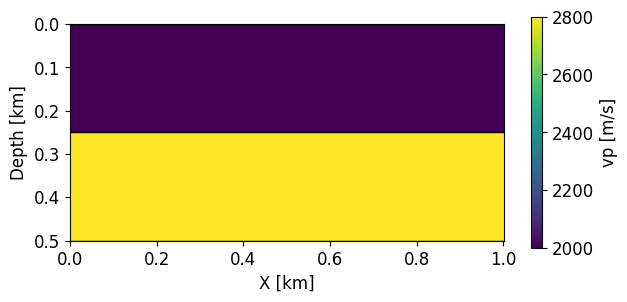

In [3]:
model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.ft)
model.add_layer(
    name="upper_layer",
    properties={
        "Vp": 2000 * u.m / u.s,
        "Rho": 2.2 * u.g / u.cm**3,
    },
)
model.add_surface(name="interface", depth=250 * u.m)
model.add_layer(
    name="lower_layer",
    properties={
        "Vp": 2800 * u.m / u.s,
        "Rho": 2.4 * u.g / u.cm**3,
    },
)
model.add_surface(name="bottom", depth=500 * u.m)

sim += model
model.plot("vp", figsize=(7, 3), aspect="equal")


## Mesh, Order, And Wavelength Sizing

The mesh generator creates the initial geometric mesh from the model bounds and surfaces. `sim.mesh.set_adapt(...)` then tells the solver how to size the adapted mesh for the wavefield. `order` is the finite-element polynomial order. `elems_per_wave` is the requested minimum number of elements per shortest wavelength after adaptivity.

A useful first estimate for points per wavelength is `order * elems_per_wave + 1`; with `order=4` and `elems_per_wave=2`, the adapted solve has roughly nine nodal points per wavelength before details such as element family and output interpolation are considered.

The PML is not authored as an extra geological layer. When a boundary is marked `pml`, the solver auto-extrudes an absorbing layer outside that model boundary. The physical PML thickness is frequency-dependent because `pml_wavelengths` is measured in local wavelengths: lower frequencies imply longer wavelengths and therefore wider physical PMLs, while higher frequencies imply thinner physical PMLs for the same setting.


## Boundary Conditions And PML

Boundary conditions are attached after the model and mesh generator exist because they refer to named exterior boundaries such as `x_min`, `x_max`, `z_min`, and `z_max`. This notebook uses a free top boundary and PML on the side and bottom truncation boundaries.

| Boundary condition | Variables/components constrained | Typical use |
| --- | --- | --- |
| `free` | Natural acoustic boundary for pressure $p$ and normal particle velocity $v_n$. | Free surface or an open natural boundary when no absorbing layer is desired. |
| `fixed` | Prescribed pressure trace, usually written $p$ on the boundary. | Hard or fixed-pressure idealization. |
| `impedance` | Couples pressure $p$ with normal particle velocity $v_n$ through an impedance relation. | Approximate radiation or absorbing boundary without a full PML. |
| `pml` | Absorbing-layer equations for all active acoustic fields in the auto-extruded PML region. | Truncating the computational domain on sides and bottom. |
| `symmetric` | Constrains the normal component implied by the axis/symmetry formulation. | Symmetry-reduced acoustic models. |

The PML settings below use `pml_wavelengths=0.5`, meaning the absorbing layer is extruded to about one half of the longest wavelength at a given frequency. `pml_reflection` defaults to `1e-3`, meaning that approximately 0.1% of wave energy will be reflected by the boundary. Be aware that the 'strength' per width can affect conditioning: if you want less reflected energy you may need to increase the PML width. A good target is to keep log(reflection/width) constant; so `pml_reflection=1e-6` with `pml_wavelengths=1.0` will have similar conditioning to the default.

More complete cross-physics material and boundary tables are in the user guide page `Physics, Materials, And Boundaries`.


In [4]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0)
sim.mesh.set_source_grading(d1=0.05, factor=2.0)

sim += fs.BoundaryCondition(
    conditions=["free"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=0.5,
    pml_reflection=1e-3,
)


## Acquisition

Sources and receivers use physical global coordinates by default. For now we set up a simple dense acquisition (all sources recorded by all receivers/channels). Sparse surveys, more advanced receiver and source types, and more will be covered later. We note that fs.Q_ defines a 'quantity' with units, this is often the easiest way to attach units to receiver coordinates. Units definition/use is covered in more depth in tutorial 3.2.


In [5]:
acq = fs.Acquisition()
acq.add_sources(kind="scalar", coords=fs.Q_([[500, 25]], "m"))

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")

receiver_coords = fs.Q_([[x, 50] for x in np.linspace(0, 1000, 201)], "m")
acq.add_receiver_group(name="surface", device=hydrophone, coords=receiver_coords)
sim += acq

# sim += fs.SolverConfig(
#     patch_precision="half",
# )


## Save And Inspect The Project

`site.submit(job)` saves the simulation and job automatically. Explicit saving is useful while learning because it shows the project directory structure:

- `project.json`: project manifest.
- `simulations/<simulation>/<simulation>.json`: solver simulation configuration.
- `simulations/<simulation>/<simulation>.h5`: materialized arrays when needed.
- `jobs/<simulation>/<job>/<job>.json`: job configuration.
- `jobs/<simulation>/<job>/logs`: local or fetched logs.
- `jobs/<simulation>/<job>/results`: traces, ParaView files, and run metadata.

The project is saved on submission if it has not already been saved.


In [6]:
project_file = project.save()
project_file

PosixPath('/Users/jacobbadger/omnirepo/FrequenSolve/examples/tutorials/01_modeling_basics/scratch/acoustic/project.json')

## Frequency-Domain Job

The first solver run is a `FrequencyDomainJob`. This is the native FrequenSolve workflow: the job lists the frequencies to solve, the output requests to write, and the simulation that owns the model, mesh, acquisition, and numerics.

### Sites and Submission
A site is the execution target for a job: local workstation, HPC system, or cloud environment. This notebook uses `LocalSite`, which can run only where the fast solver is installed. `site.submit(job)` returns a `RunHandle`, a small future-like object representing the submitted run; here we immediately call `handle.wait()` so the next cells can read results. Section 2 explains sites in more depth, including remote execution, polling, log/result fetching, and attaching to existing runs.

### Ouputs
Here we solve a single 25 Hz frequency and request a ParaView output (by default, these will write a VTU file and thus can be loaded by various programs). Traces are output by default and thus don't need to be explicitly requested. Note ParaView outputs currently support only first and second-order visualization, this lags the orders typically used in wavefield modeling so an additional option `upscale` is thus included that sub-divides cells. Paraview outputs will be covered in more detail in later tutorials.


In [7]:
site = fs.LocalSite(shutdown_on_completion=True, verbose=True)
pv_coarse = fs.ParaviewOutput(
    name="pv_coarse",
    properties=["Vp"],
    show_pml=True,
    upscale=0,
    order=1,
)
pv_fine = fs.ParaviewOutput(
    name="pv_fine",
    properties=["Vp"],
    fields=["pressure", "velocity_z"],
    show_pml=True,
    upscale=1,
    order=2,
)

fd_job = fs.FrequencyDomainJob(
    name="freq_50hz",
    simulation=sim,
    f_list=[50.0],
    outputs=[pv_coarse, pv_fine],
)
fd_handle = site.submit(fd_job)
fd_result = fd_handle.wait()


2026-07-01 05:18:30,476 [INFO] frequensolve.orchestrator.sites.local.site:1194 - Initializing Dask with 1 workers, 16 threads per worker, 117964MB memory per worker
2026-07-01 05:18:31,646 [INFO] frequensolve.orchestrator.sites.local.site:1283 - Dask dashboard available at http://localhost:52148/status


Site,Job,Job ID,State,Succeeded,Failed,Running,Pending,Total
LocalSite,freq_50hz,local:freq_50hz,failed,-,-,-,-,-


## Inspect The VTU Output

The ParaView request writes a VTU file, which is a standard VTK unstructured-grid file that can be opened directly in ParaView for interactive mesh, material-property, and wavefield inspection. For convenience, the Python SDK can also open VTU files through PyVista; the next cell reads the file and lists the fields that can be plotted.


In [8]:
vtu_files = fd_result.output_files(suffix=".vtu", existing=True)
for file in vtu_files:
    mesh = fs.read_vtu(file)
    print(f"File: {file}\nFields:")
    for field in fs.vtu_fields(mesh):
        print(f"\t{field}")


/Users/jacobbadger/omnirepo/FrequenSolve/.venv/lib/python3.10/site-packages/pyvista/core/_vtk_core.py:17: RuntimeWarning: coroutine 'FutureState.wait' was never awaited
  from vtkmodules.vtkCommonCore import vtkInformation as vtkInformation


File: /Users/jacobbadger/omnirepo/FrequenSolve/examples/tutorials/01_modeling_basics/scratch/acoustic/jobs/acoustic_basic/freq_50hz/results/ParaView/pv_coarse_00000.vtu
Fields:
	Vp
File: /Users/jacobbadger/omnirepo/FrequenSolve/examples/tutorials/01_modeling_basics/scratch/acoustic/jobs/acoustic_basic/freq_50hz/results/ParaView/pv_fine_00000.vtu
Fields:
	Vp
	pressure_1_im
	pressure_1_re
	pressure_1_abs
	velocity_z_1_im
	velocity_z_1_re
	velocity_z_1_abs


## Render A Persistent PyVista Screenshot

The VTU files can be opened directly in ParaView for full interactive inspection. For a tutorial notebook, it is also useful to render a static PyVista screenshot and save it under `assets/` so readers can see the frequency-domain output after reopening the notebook without a live PyVista window.

This view plots the acoustic wavespeed on the exported mesh with element edges enabled. In a real QC pass, this is the first visual check: confirm that the layer geometry, PML extrusion, and material labels agree with the authored model before interpreting wavefields.


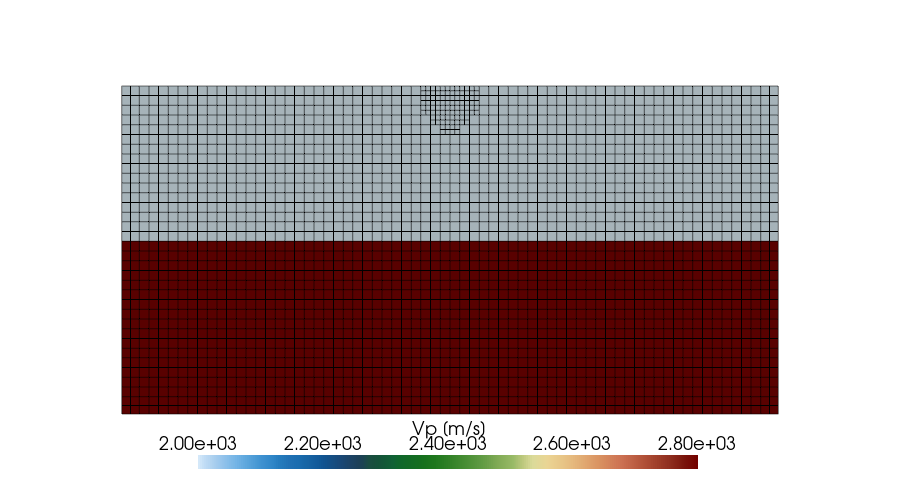

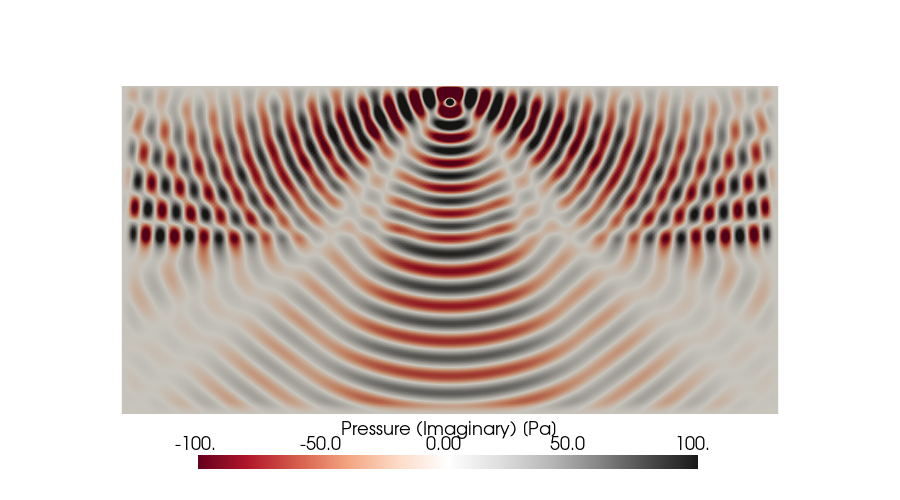

In [9]:
image_dir = Path("./assets")
image_dir.mkdir(exist_ok=True)
mesh_screenshot = image_dir / "acoustic_mesh.png"
pressure_screenshot = image_dir / "acoustic_pressure.png"

if vtu_files:
    fs.plot_vtu(
        vtu_files[0],
        field="Vp",
        show_edges=True,
        scalar_bar=True,
        show=False,
        cmap=fs.BuGrOr,
        zoom=1.5,
        screenshot=mesh_screenshot,
        window_size=(900, 500),
    )
    fs.plot_vtu(
        vtu_files[1],
        field="pressure",
        part="im",
        scalar_bar=True,
        show=False,
        vmin=-100.0,
        vmax=100.0,
        cmap="RdGy",
        zoom=1.5,
        screenshot=pressure_screenshot,
        window_size=(900, 500),
    )

display(Image(filename=str(mesh_screenshot)))
display(Image(filename=str(pressure_screenshot)))


## Time-Domain Job

While FrequenSolve relies primarily on frequency-domain modeling, we've done our best to make time-domain modeling a first-class entity in the FrequenSolve Python SDK. A `TimeDomainJob` simply expands the required frequencies, simulates them independently, and then reconstructs the time-domain traces. This is illustrated by printing the first frequency 'tasks' below. You may notice the actual frequencies are complex-valued, this is to support Laplace-Fourier domain modeling which can be very useful for time-domain reconstruction; we'll return to this in a later tutorial.

The returned `RunResult` exposes a `TraceDataset` for reading either frequency-domain or reconstructed time-domain data.

In [10]:
td_job = fs.TimeDomainJob(
    name="time",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=2.0,
)

print(f"\nFrequency tasks for job: {td_job.name}")
for i,f in enumerate(td_job.f_list[:10]):
    print(f"   Task {i}: {f.real} + {f.imag}i Hz")
print("   ...\n")

handle = site.submit(td_job)
result = handle.wait()

traces = result.traces(upscale=4)
traces.summary


2026-07-01 05:18:34,413 [INFO] frequensolve.orchestrator.sites.local.site:1194 - Initializing Dask with 1 workers, 16 threads per worker, 117964MB memory per worker



Frequency tasks for job: time
   Task 0: 0.5 + 0.0i Hz
   Task 1: 1.0 + 0.0i Hz
   Task 2: 1.5 + 0.0i Hz
   Task 3: 2.0 + 0.0i Hz
   Task 4: 2.5 + 0.0i Hz
   Task 5: 3.0 + 0.0i Hz
   Task 6: 3.5 + 0.0i Hz
   Task 7: 4.0 + 0.0i Hz
   Task 8: 4.5 + 0.0i Hz
   Task 9: 5.0 + 0.0i Hz
   ...



2026-07-01 05:18:35,425 [INFO] frequensolve.orchestrator.sites.local.site:1283 - Dask dashboard available at http://localhost:52161/status
2026-07-01 05:18:35,763 [INFO] frequensolve.orchestrator.sites.local.site:1305 - Refreshing Dask cluster for 90 pending tasks
2026-07-01 05:18:35,780 [INFO] frequensolve.orchestrator.sites.local.site:1194 - Initializing Dask with 16 workers, 1 threads per worker, 7372MB memory per worker
2026-07-01 05:18:37,606 [INFO] frequensolve.orchestrator.sites.local.site:1283 - Dask dashboard available at http://localhost:52173/status


Site,Job,Job ID,State,Succeeded,Failed,Running,Pending,Total
LocalSite,time,local:time,failed,-,-,-,-,-


surface
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['p']
  Frequencies	: 0.50 - 45.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

## Plot Time-Domain Traces

`RunResult.traces()` returns a `TraceDataset`. Frequency-domain reads use `traces.fd(...)`; time-domain reads use `traces.td(...)` and require a wavelet. The Ricker wavelet below is applied during reconstruction so the plotted gather represents the source signature you want to analyze. Plotting helpers operate on normal `xarray.DataArray` objects.


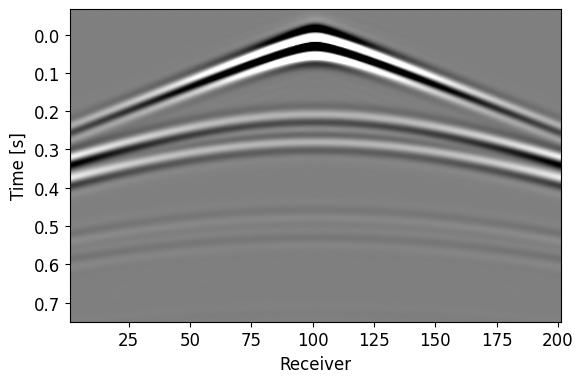

: 

In [ ]:
wavelet = fs.RickerWavelet(f=15.0)
group = traces.groups[0]
component = traces.components(group)[0]
source = traces.sources(group)[0]

gather = traces.td(group, component, source, wavelet, upscale=4, T_max = 0.75)
fig, ax = fs.plot_gather(
    gather,
    A=2.0 * np.std(np.abs(gather.values)),
    cmap="gray",
    figsize=(6, 4),
)
